# BERTopic Hyperparameter Optimization (Supervised Approach)

In this notebook, I applied BERTopic to perform topic modeling on textual data. First, I used an unsupervised approach to automatically discover latent topics based on semantic similarity between documents.

Next, I optimized key model hyperparameters to improve topic quality, evaluating the results using topic coherence, topic diversity, and the number of topics. This allowed me to select a configuration that balances interpretability and topic separation.

Finally, I applied supervised topic modeling by incorporating predefined report sections as labels. This helped generate more structured and interpretable topics aligned with the report structure.

Overall, the notebook demonstrates a complete topic modeling workflow, from exploration to optimization and evaluation.


In [1]:
%pip install pandas==2.1.4 pyarrow==14.0.2



Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

path = r"output.csv"
df = pd.read_csv(path)

df.head()


,year,country,is_eu,section,source_file,chunk_id,text
0,2013,Afghanistan,False,EXECUTIVE SUMMARY,Afghanistan.txt,Afghanistan.txt::EXECUTIVE SUMMARY::0,Share Afghanistan is an Islamic republic with ...
1,2013,Afghanistan,False,Section 1.,Afghanistan.txt,Afghanistan.txt::Section 1.::0,"Respect for the Integrity of the Person, Inclu..."
2,2013,Afghanistan,False,Section 1.,Afghanistan.txt,Afghanistan.txt::Section 1.::1,"judges, prosecutors, and clerical staff. In Ju..."
3,2013,Afghanistan,False,Section 1.,Afghanistan.txt,Afghanistan.txt::Section 1.::2,were reports that insurgent groups were respon...
4,2013,Afghanistan,False,Section 1.,Afghanistan.txt,Afghanistan.txt::Section 1.::3,with fists and electric cables; kicking; choki...


In [7]:
df.groupby(["year"])["country"].nunique(), df["is_eu"].mean()

(year
 2013    195
 2014    195
 2015    195
 Name: country, dtype: int64,
 0.10293074481986186)

In [8]:
docs_all = df["text"].tolist()
tokenized_docs = [d.split() for d in docs_all]


UNSUPERVISED TOPIC MODELING (BERTopic)

In [5]:
%pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.9.1+cpuNote: you may need to restart the kernel to use updated packages.

Uninstalling torch-2.9.1+cpu:
  Successfully uninstalled torch-2.9.1+cpu
Found existing installation: torchvision 0.24.1+cpu
Uninstalling torchvision-0.24.1+cpu:
  Successfully uninstalled torchvision-0.24.1+cpu
Found existing installation: torchaudio 2.9.1+cpu
Uninstalling torchaudio-2.9.1+cpu:
  Successfully uninstalled torchaudio-2.9.1+cpu


In [6]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpuNote: you may need to restart the kernel to use updated packages.

  Using cached https://download.pytorch.org/whl/cpu/torch-2.9.1%2Bcpu-cp310-cp310-win_amd64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.24.1%2Bcpu-cp310-cp310-win_amd64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.9.1%2Bcpu-cp310-cp310-win_amd64.whl.metadata (7.0 kB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.9.1%2Bcpu-cp310-cp310-win_amd64.whl (110.9 MB)
Using cached https://download.pytorch.org/whl/cpu/torchvision-0.24.1%2Bcpu-cp310-cp310-win_amd64.whl (3.7 MB)
Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.9.1%2Bcpu-cp310-cp310-win_amd64.whl (661 kB)

   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   -----------------------------

In [9]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install sentence-transformers


Note: you may need to restart the kernel to use updated packages.


In [9]:
# Install the required libraries

from sentence_transformers import SentenceTransformer


# Use CPU-only version of PyTorch to avoid DLL initialization errors
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
embeddings = embedding_model.encode(
    docs_all,
    show_progress_bar=True
)


Batches: 100%|██████████| 838/838 [29:00<00:00,  2.08s/it]


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2)
)


In [11]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=3,
    min_samples=1,
    metric="euclidean"
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics="auto",        # safety net
    verbose=True
)

In [12]:
%pip install bertopic==0.16.0


  Attempting uninstall: bertopic
    Found existing installation: bertopic 0.17.4
    Uninstalling bertopic-0.17.4:
      Successfully uninstalled bertopic-0.17.4


In [13]:
topics, probs = topic_model.fit_transform(docs_all, embeddings)


2026-01-18 23:23:34,011 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-18 23:24:27,652 - BERTopic - Dimensionality - Completed ✓
2026-01-18 23:24:27,655 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-18 23:24:36,248 - BERTopic - Cluster - Completed ✓
2026-01-18 23:24:36,248 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-01-18 23:24:50,813 - BERTopic - Representation - Completed ✓
2026-01-18 23:24:50,829 - BERTopic - Topic reduction - Reducing number of topics
2026-01-18 23:25:08,909 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-18 23:25:24,874 - BERTopic - Representation - Completed ✓
2026-01-18 23:25:24,906 - BERTopic - Topic reduction - Reduced number of topics from 3533 to 1988


In [14]:
topic_model.get_topic_info().head()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,7469,-1_detention_law_police_authorities,"[detention, law, police, authorities, prison, ...",[trade union officials to identify forced labo...
1,0,2645,0_labor_child labor_workers_unions,"[labor, child labor, workers, unions, employer...",[enforced. The ministry provided no informatio...
2,1,945,1_international child_marriage_pornography_sex...,"[international child, marriage, pornography, s...","[legal age for marriage is 18, but parents, wi..."
3,2,760,2_defendants_pretrial detention_bail_trial,"[defendants, pretrial detention, bail, trial, ...","[provides for an independent judiciary, and th..."
4,3,681,3_corruption_disclosure_public access_financia...,"[corruption, disclosure, public access, financ...",[Corruption and Lack of Transparency in Govern...


In [15]:
topic_info = topic_model.get_topic_info().copy()

# Exclude outliers for interpretation
main_topics = topic_info[topic_info["Topic"] != -1].copy()

# Add share
main_topics["share"] = main_topics["Count"] / main_topics["Count"].sum()

main_topics.head(30)[["Topic","Count","share","Name"]]


,Topic,Count,share,Name
1,0,2645,0.136933,0_labor_child labor_workers_unions
2,1,945,0.048923,1_international child_marriage_pornography_sex...
3,2,760,0.039346,2_defendants_pretrial detention_bail_trial
4,3,681,0.035256,3_corruption_disclosure_public access_financia...
5,4,544,0.028163,4_elections_participation_change government_fr...
6,5,507,0.026248,5_lgbt_aids_hiv_hiv aids
7,6,358,0.018534,6_rape_spousal_rape domestic_spousal rape
8,7,250,0.012943,7_freedom speech_speech_speech press_press
9,8,220,0.011390,8_independent monitoring_arrest detention_arbi...
10,9,210,0.010872,9_prisons_inmates_prisoners_juveniles


In [16]:
valid_topic_ids = [
    t for t in set(topics)
    if t != -1
]

len(valid_topic_ids)


1987

In [17]:
def extract_topic_words(model, topic_ids, topn=10):
    topic_words = []

    for tid in topic_ids:
        topic = model.get_topic(tid)

        # 🔴 skip empty or invalid topics
        if topic is None:
            continue

        words = [w for w, _ in topic if isinstance(w, str)]

        if len(words) >= 2:  # Gensim needs at least 2 words
            topic_words.append(words[:topn])



    return topic_words


In [18]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def coherence_cv(tokenized_docs, topic_words):
    dictionary = Dictionary(tokenized_docs)

    # ╓ remove words not in dictionary
    filtered_topics = [
        [w for w in topic if w in dictionary.token2id]
        for topic in topic_words
    ]

    filtered_topics = [t for t in filtered_topics if len(t) >= 2]

    corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

    cm = CoherenceModel(
        topics=filtered_topics,
        texts=tokenized_docs,
        corpus=corpus,
        dictionary=dictionary,
        coherence="c_v"
    )

    return cm.get_coherence()

In [20]:

def topic_diversity(topic_words, topk=10):
    all_words = []
    for words in topic_words:
        all_words.extend(words[:topk])
    return len(set(all_words)) / len(all_words)




In [21]:
topic_words = extract_topic_words(
    topic_model,
    valid_topic_ids,
    topn=10
)

len(topic_words)

1987

In [22]:
coh = coherence_cv(tokenized_docs, topic_words)
div = topic_diversity(topic_words)


hyperparametr optimization

In [23]:
base_params = {
    "n_neighbors": 10,
    "n_components": 5,
    "min_cluster_size": 3,
    "min_samples": 1
}


In [24]:
configs = [
    {**base_params},  # baseline
    {**base_params, "min_cluster_size": 5},
    {**base_params, "n_neighbors": 15},
]


In [25]:
def build_model_from_params(params):
    umap_model = UMAP(
        n_neighbors=params["n_neighbors"],
        n_components=params["n_components"],
        metric="cosine",
        random_state=42
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=params["min_cluster_size"],
        min_samples=params["min_samples"],
        metric="euclidean"
    )

    model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        nr_topics="auto",
        verbose=False
    )

    return model


In [26]:
results = []

for i, params in enumerate(configs):
    print(f"Running config {i+1}: {params}")

    model = build_model_from_params(params)
    topics, _ = model.fit_transform(docs_all, embeddings)

    valid_topic_ids = [t for t in set(topics) if t != -1]

    topic_words = extract_topic_words(model, valid_topic_ids, topn=10)

    if len(topic_words) < 2:
        print("  → skipped (too few valid topics)")
        continue

    coh = coherence_cv(tokenized_docs, topic_words)
    div = topic_diversity(topic_words)

    results.append({
        "config_id": i + 1,
        **params,
        "n_topics": len(topic_words),
        "coherence_c_v": coh,
        "topic_diversity": div
    })


Running config 1: {'n_neighbors': 10, 'n_components': 5, 'min_cluster_size': 3, 'min_samples': 1}
Running config 2: {'n_neighbors': 10, 'n_components': 5, 'min_cluster_size': 5, 'min_samples': 1}
Running config 3: {'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 3, 'min_samples': 1}


In [27]:
results_df = pd.DataFrame(results)
results_df


,config_id,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,coherence_c_v,topic_diversity
0,1,10,5,3,1,1987,0.674265,0.777906
1,2,10,5,5,1,616,0.698693,0.704221
2,3,15,5,3,1,1814,0.665277,0.767806


In [28]:
results_df["score"] = (
    0.7 * results_df["coherence_c_v"] +
    0.3 * results_df["topic_diversity"]
)

results_df.sort_values("score", ascending=False)


,config_id,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,coherence_c_v,topic_diversity,score
0,1,10,5,3,1,1987,0.674265,0.777906,0.705357
1,2,10,5,5,1,616,0.698693,0.704221,0.700351
2,3,15,5,3,1,1814,0.665277,0.767806,0.696036


In [29]:
best_params = results_df.sort_values(
    "score", ascending=False
).iloc[0]

best_params = {
    "n_neighbors": int(best_params["n_neighbors"]),
    "n_components": int(best_params["n_components"]),
    "min_cluster_size": int(best_params["min_cluster_size"]),
    "min_samples": int(best_params["min_samples"]),
}


In [30]:
best_model = build_model_from_params(best_params)
topics, _ = best_model.fit_transform(docs_all, embeddings)


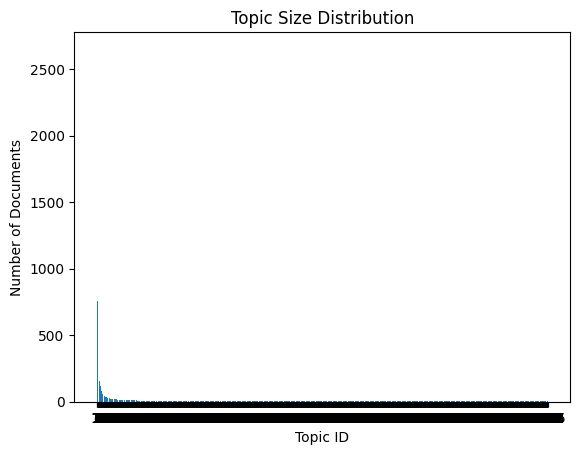

In [31]:
import matplotlib.pyplot as plt

topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info.Topic != -1]

plt.figure()
plt.bar(
    topic_info.Topic.astype(str),
    topic_info.Count
)
plt.xlabel("Topic ID")
plt.ylabel("Number of Documents")
plt.title("Topic Size Distribution")
plt.show()


In [32]:
best_model.get_topic_info()
for t in range(5):
    print(f"Topic {t}:")
    print(best_model.get_topic(t))
    print()


Topic 0:
[('labor', 0.0027317426047690314), ('child labor', 0.0025780996790369256), ('workers', 0.0024748027001118347), ('unions', 0.0023348095844383456), ('employers', 0.0020979932140885215), ('overtime', 0.002088787711293555), ('wage', 0.0020604320809860673), ('minimum', 0.0020548093108511806), ('work', 0.0020536818983541145), ('collective', 0.002035769876613513)]

Topic 1:
[('international child', 0.00356737510638281), ('marriage', 0.00315842988442407), ('pornography', 0.002950470733576912), ('sexual exploitation', 0.002867976076429119), ('child pornography', 0.002814755003528001), ('exploitation children', 0.002796419821807799), ('girls', 0.0026811613096728746), ('child abuse', 0.002663490741074757), ('abduction', 0.0026104912604899395), ('child abduction', 0.0025817765581941147)]

Topic 2:
[('defendants', 0.004102534422152162), ('pretrial detention', 0.003368992267047021), ('bail', 0.003357235989369763), ('trial', 0.0032394374186561752), ('pretrial', 0.0031936808322853673), ('coun

In [33]:
best_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7469,-1_detention_law_police_authorities,"[detention, law, police, authorities, prison, ...",[trade union officials to identify forced labo...
1,0,2645,0_labor_child labor_workers_unions,"[labor, child labor, workers, unions, employer...",[enforced. The ministry provided no informatio...
2,1,945,1_international child_marriage_pornography_sex...,"[international child, marriage, pornography, s...","[legal age for marriage is 18, but parents, wi..."
3,2,760,2_defendants_pretrial detention_bail_trial,"[defendants, pretrial detention, bail, trial, ...","[provides for an independent judiciary, and th..."
4,3,681,3_corruption_disclosure_public access_financia...,"[corruption, disclosure, public access, financ...",[Corruption and Lack of Transparency in Govern...
...,...,...,...,...,...
1983,1982,3,1982_jang_public executions_dprk_executed,"[jang, public executions, dprk, executed, exec...",[executed for various reasons since Kim Jong U...
1984,1983,3,1983_camp_kwan_kwan li_yodok,"[camp, kwan, kwan li, yodok, hamkyung, hamkyun...","[contained unmarked graves, barracks, worksite..."
1985,1984,3,1984_gbagbo_icc_simone gbagbo_simone,"[gbagbo, icc, simone gbagbo, simone, il, abdou...","[Respect for the Integrity of the Person, Incl..."
1986,1985,3,1985_songbun_hrnk_dprk_loyalty,"[songbun, hrnk, dprk, loyalty, placed citizens...","[place of residence, medical facilities, certa..."


In [34]:
topic_info = best_model.get_topic_info().copy()

# Exclude outliers for interpretation
main_topics = topic_info[topic_info["Topic"] != -1].copy()

# Add share
main_topics["share"] = main_topics["Count"] / main_topics["Count"].sum()

main_topics.head(30)[["Topic","Count","share","Name"]]


,Topic,Count,share,Name
1,0,2645,0.136933,0_labor_child labor_workers_unions
2,1,945,0.048923,1_international child_marriage_pornography_sex...
3,2,760,0.039346,2_defendants_pretrial detention_bail_trial
4,3,681,0.035256,3_corruption_disclosure_public access_financia...
5,4,544,0.028163,4_elections_participation_change government_fr...
6,5,507,0.026248,5_lgbt_aids_hiv_hiv aids
7,6,358,0.018534,6_rape_spousal_rape domestic_spousal rape
8,7,250,0.012943,7_freedom speech_speech_speech press_press
9,8,220,0.011390,8_independent monitoring_arrest detention_arbi...
10,9,210,0.010872,9_prisons_inmates_prisoners_juveniles


In [35]:
docs = best_model.get_representative_docs(1)

for d in docs[:3]:
    print(d[:300])
    print("----")


legal age for marriage is 18, but parents, with informed consent of the minor, may secure a waiver from a judge for underage marriage. The judiciary approved the vast majority of petitions for underage marriages. Child marriage remained a concern. Sexual Exploitation of Children : The age of consent
----
criminal offense. The law establishes a penalty of two years’ imprisonment for persons convicted of publishing or offering for sale any obscene book, writing, or representation. International Child Abductions : The country is a party to the 1980 Hague Convention on the Civil Aspects of International
----
Forced Marriage : The legal minimum age for marriage is 18 years for men and women but 16 with parental consent. Underage marriage was rare, and the government kept no statistics on it. Female Genital Mutilation/Cutting (FGM/C) : There is no law that prohibits Female Genital Mutilation/Cutting, and 
----


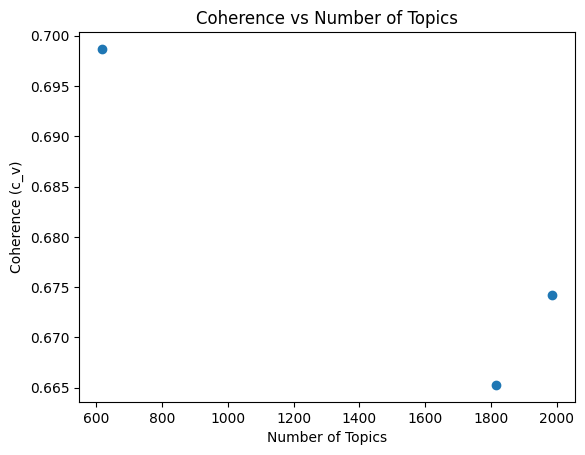

In [36]:
plt.figure()
plt.scatter(
    results_df["n_topics"],
    results_df["coherence_c_v"]
)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence (c_v)")
plt.title("Coherence vs Number of Topics")
plt.show()


SUPERVISED TOPIC MODELING BY REPORT SECTION

In [37]:
df["section"].value_counts().head()

section
Section 1.    7300
Section 6.    6761
Section 2.    4568
Section 7.    4287
Section 4.    1261
Name: count, dtype: int64

In [38]:
sections = [ "Section 1.", "Section 6.", "Section 2."]

In [39]:
def run_bertopic_on_subset(docs, embeddings_subset=None):
    topics, _ = topic_model.fit_transform(docs, embeddings_subset)
    topic_info = topic_model.get_topic_info()
    topic_info = topic_info[topic_info.Topic != -1]  # remove outliers
    return topic_info


In [40]:
results_by_section = {}

for sec in sections:
    subset = df[df["section"] == sec]["text"].tolist()

    if len(subset) < 100:
        continue  # skip tiny sections

    topics, _ = topic_model.fit_transform(subset)

    results_by_section[sec] = topic_model.get_topic_info()


Batches: 100%|██████████| 229/229 [07:50<00:00,  2.06s/it]
2026-01-18 23:44:36,694 - BERTopic - Embedding - Completed ✓
2026-01-18 23:44:36,695 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-18 23:44:48,281 - BERTopic - Dimensionality - Completed ✓
2026-01-18 23:44:48,281 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-18 23:44:48,667 - BERTopic - Cluster - Completed ✓
2026-01-18 23:44:48,667 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-01-18 23:44:53,006 - BERTopic - Representation - Completed ✓
2026-01-18 23:44:53,014 - BERTopic - Topic reduction - Reducing number of topics
2026-01-18 23:44:54,632 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-18 23:44:57,995 - BERTopic - Representation - Completed ✓
2026-01-18 23:44:58,002 - BERTopic - Topic reduction - Reduced number of topics from 1052 to 30
2026-01-18 23:44:58,486 - BERTopic - Embedding -

In [41]:
for sec, info in results_by_section.items():
    print(f"\n=== {sec} ===")
    display(info.head(5))



=== Section 1. ===


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1808,-1_police_detention_authorities_government,"[police, detention, authorities, government, p...","[Respect for the Integrity of the Person, Incl..."
1,0,5373,0_police_government_prison_detention,"[police, government, prison, detention, author...",[visitors and were permitted religious observa...
2,1,17,1_kachin_shan_ethnic_army,"[kachin, shan, ethnic, army, cease, state, lan...","[development, tourism, and natural resource ex..."
3,2,7,2_land_owners_jaffna_acquisition,"[land, owners, jaffna, acquisition, lands, dis...",[and for failing to “gazette” (publish officia...
4,3,6,3_zanu pf_zanu_pf_mdc,"[zanu pf, zanu, pf, mdc, supporters, pf suppor...","[to their barracks. Once there, the soldiers a..."



=== Section 6. ===


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1423,-1_women_children_law_persons,"[women, children, law, persons, violence, sexu...",[two years after a birth or adoption. Accordin...
1,0,5148,0_women_persons_children_law,"[women, persons, children, law, violence, sexu...","[Discrimination, Societal Abuses, and Traffick..."
2,1,16,1_dalit_dalits_caste_manual,"[dalit, dalits, caste, manual, upper, castes, ...",[to prosecute perpetrators or because victims ...
3,2,16,2_bedouin_arab_villages_land,"[bedouin, arab, villages, land, unrecognized, ...","[For example, Adalah highlighted the extreme d..."
4,3,13,3_kurdish_kirkuk_arabs_kurds,"[kurdish, kirkuk, arabs, kurds, palestinians, ...",[of Social Affairs and Labor is responsible fo...



=== Section 2. ===


,Topic,Count,Name,Representation,Representative_Docs
0,-1,936,-1_freedom_refugees_law_internet,"[freedom, refugees, law, internet, media, coun...",[Freedom of Peaceful Assembly and Association ...
1,0,3140,0_freedom_refugees_asylum_law,"[freedom, refugees, asylum, law, persons, coun...","[Respect for Civil Liberties, Including: Share..."
2,1,17,1_ccp_books_liu_propaganda department,"[ccp, books, liu, propaganda department, state...","[reform, ethnic discrimination, and corruption..."
3,2,16,2_tibetans_tibetan_tibetan refugees_nepal,"[tibetans, tibetan, tibetan refugees, nepal, n...",[The CTA did not have an official presence in ...
4,3,11,3_citizenship_children_father_saudi,"[citizenship, children, father, saudi, nonciti...","[obtained a second nationality, which is again..."


In [42]:
for sec in results_by_section:
    results_by_section[sec] = results_by_section[sec][
        results_by_section[sec]["Topic"] != -1
    ]

In [43]:
comparison_rows = []

for sec, info in results_by_section.items():
    for _, row in info.iterrows():
        comparison_rows.append({
            "section": sec,
            "topic_id": row["Topic"],
            "n_documents": row["Count"],
            "top_words": row["Name"]
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.head()


,section,topic_id,n_documents,top_words
0,Section 1.,0,5373,0_police_government_prison_detention
1,Section 1.,1,17,1_kachin_shan_ethnic_army
2,Section 1.,2,7,2_land_owners_jaffna_acquisition
3,Section 1.,3,6,3_zanu pf_zanu_pf_mdc
4,Section 1.,4,6,4_rio_rio janeiro_janeiro_favelas


In [44]:
comparison_df.sort_values(
    ["section", "n_documents"],
    ascending=[True, False]
).head(15)


,section,topic_id,n_documents,top_words
0,Section 1.,0,5373,0_police_government_prison_detention
1,Section 1.,1,17,1_kachin_shan_ethnic_army
2,Section 1.,2,7,2_land_owners_jaffna_acquisition
3,Section 1.,3,6,3_zanu pf_zanu_pf_mdc
4,Section 1.,4,6,4_rio_rio janeiro_janeiro_favelas
5,Section 1.,5,5,5_marriages_marry_rohingya_directive
6,Section 1.,6,5,6_caprivi_defendants_remaining_separatists
7,Section 1.,7,5,7_jerusalem_jewish_orthodox_marriages
8,Section 1.,8,4,8_mass_mass graves_remains_graves
9,Section 1.,9,4,9_maoist_conflict era_era_fast


In [45]:
topic_counts = comparison_df.groupby("section")["topic_id"].nunique()
topic_counts


section
Section 1.     29
Section 2.    114
Section 6.     40
Name: topic_id, dtype: int64

In [46]:
df_topics = df.copy()   # Create a copy of the original DataFrame
df_topics["topic"] = best_model.topics_ # Use the topics from the best_model, which was fitted on all documents
df_topics = df_topics[df_topics["topic"] != -1]

In [47]:
topic_year = (
    df_topics
    .groupby(["year", "topic"])
    .size()
    .reset_index(name="count")
)

topic_year["share"] = (
    topic_year["count"] /
    topic_year.groupby("year")["count"].transform("sum")
)

In [48]:
eu_df = df_topics[df_topics["is_eu"] == 1]
non_eu_df = df_topics[df_topics["is_eu"] == 0]

In [49]:
eu_topics = eu_df["topic"].value_counts(normalize=True)
non_eu_topics = non_eu_df["topic"].value_counts(normalize=True)

In [50]:
topic_compare = pd.DataFrame({
    "EU": eu_topics,
    "Non_EU": non_eu_topics
}).fillna(0)
topic_compare["difference"] = abs(topic_compare["EU"] - topic_compare["Non_EU"])
distinct_topics = topic_compare.sort_values("difference", ascending=False).head(5)

In [51]:
# Create topic -> name mapping using top keywords
topic_labels = {
    topic: ", ".join([word for word, _ in best_model.get_topic(topic)[:5]])
    for topic in best_model.get_topics().keys()
    if topic != -1
}
df_topics["topic_name"] = df_topics["topic"].map(topic_labels)

In [52]:
df_topics['EU_status'] = df_topics['is_eu'].map({True: 'EU', False: 'Non-EU'})

# Group by EU_status and topic_name, and count occurrences
topic_counts_by_region = df_topics.groupby(["EU_status", "topic_name"]).size().reset_index(name='count')

# Calculate the share of each topic within its EU_status group
topic_counts_by_region['share'] = topic_counts_by_region.groupby("EU_status")['count'].transform(lambda x: x / x.sum())

# Now topic_region_pivot can be created from this DataFrame
topic_region_pivot = topic_counts_by_region.pivot(
    index="topic_name",
    columns="EU_status",
    values="share"
).fillna(0)

topic_region_pivot.columns = ["Non-EU", "EU"]

In [53]:
from collections import Counter

def extract_keywords_from_topic_name(topic_name):
    # "police / authorities / detention / prison"
    return [w.strip() for w in topic_name.split("/")]


In [54]:
def auto_section_label(section_df, top_k=4):
    counter = Counter()

    for _, row in section_df.iterrows():
        words = extract_keywords_from_topic_name(row["topic_name"])
        # Her chunk = 1 oy (istersen ağırlık ekleyebiliriz)
        for w in words:
            counter[w] += 1

    top_words = [w for w, _ in counter.most_common(top_k)]
    return " / ".join(top_words)


In [55]:
section_labels_df = (
    df_topics
    .groupby("section")
    .apply(auto_section_label)
    .reset_index()
)

section_labels_df.columns = ["section", "section_label_auto"]

section_labels_df

,section,section_label_auto
0,EXECUTIVE SUMMARY,"elections, participation, change government, f..."
1,Section 1.,"defendants, pretrial detention, bail, trial, p..."
2,Section 2.,"freedom speech, speech, speech press, press, i..."
3,Section 3.,"elections, participation, change government, f..."
4,Section 4.,"corruption, disclosure, public access, financi..."
5,Section 5.,"ombudsman, rights bodies, government human, pu..."
6,Section 6.,"international child, marriage, pornography, se..."
7,Section 7.,"labor, child labor, workers, unions, employers..."


In [56]:
import pandas as pd

def get_main_phrase(label):
    """
    Virgülle ayrılmış uzun label içinden
    en baskın (ilk) kısmı alır
    """
    if pd.isna(label):
        return ""
    return label.split(",")[0]


In [57]:
def short_label_2_words(label):
    main = get_main_phrase(label)
    words = main.split()
    return " ".join(words[:2])


In [58]:
section_labels_df["section_label_short"] = (
    section_labels_df["section_label_auto"]
    .apply(short_label_2_words)
)


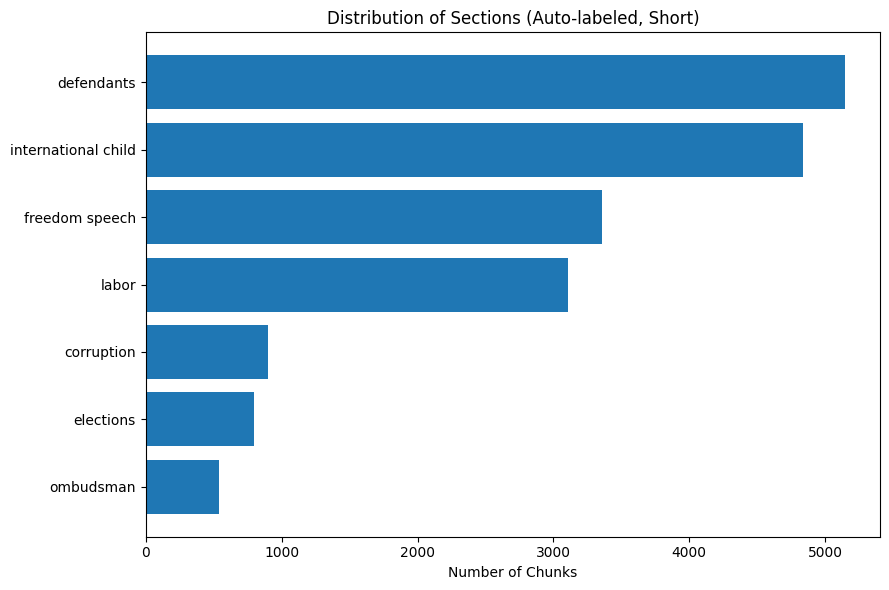

In [59]:
section_counts = (
    df_topics
    .groupby("section")
    .size()
    .reset_index(name="n_chunks")
    .merge(section_labels_df, on="section", how="left")
    .sort_values("n_chunks")
)

plt.figure(figsize=(9, 6))
plt.barh(
    section_counts["section_label_short"],
    section_counts["n_chunks"]
)

plt.xlabel("Number of Chunks")
plt.title("Distribution of Sections (Auto-labeled, Short)")
plt.tight_layout()
plt.show()


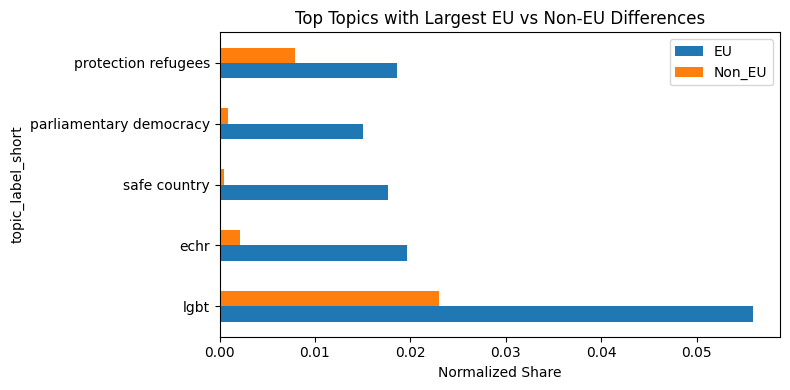

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------
# 1. Ultra-short topic label creator
# ----------------------------------
def ultra_short_label(label):
    """
    Converts long topic labels into 1–2 word concept labels.
    Example:
    'corruption, disclosure, public access, financial disclosure'
    -> 'corruption'
    """
    if pd.isna(label):
        return "unknown"

    # split by comma or slash
    tokens = (
        label
        .replace("/", ",")
        .split(",")
    )

    # take first meaningful token
    main = tokens[0].strip()

    # keep at most 2 words
    return " ".join(main.split()[:2])


# ----------------------------------
# 2. Prepare plotting dataframe
# ----------------------------------
plot_df = distinct_topics.copy().reset_index()
plot_df.columns = ["topic", "EU", "Non_EU", "difference"]

# use EXISTING topic_labels
plot_df["topic_label_full"] = plot_df["topic"].map(topic_labels)

# create ultra-short labels (like your example)
plot_df["topic_label_short"] = plot_df["topic_label_full"].apply(
    ultra_short_label
)

# use short labels as index
plot_df = plot_df.set_index("topic_label_short")


# ----------------------------------
# 3. Visualization (clean & compact)
# ----------------------------------
plot_df[["EU", "Non_EU"]].plot(
    kind="barh",
    figsize=(8, 4)
)

plt.xlabel("Normalized Share")
plt.title("Top Topics with Largest EU vs Non-EU Differences")
plt.tight_layout()
plt.show()


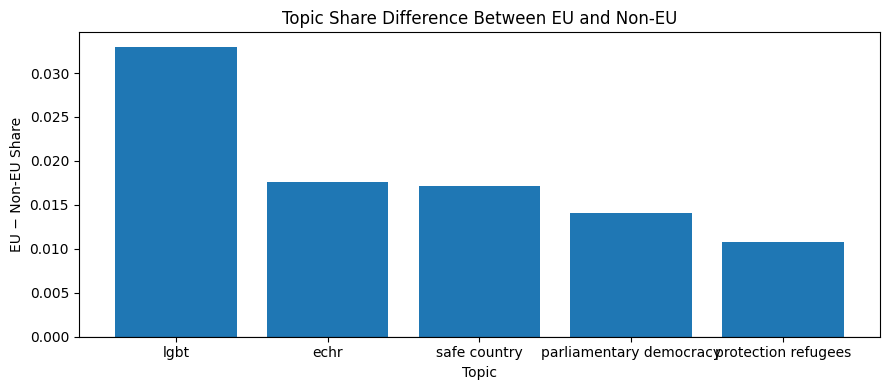

In [61]:
plot_df["diff"] = plot_df["EU"] - plot_df["Non_EU"]

plt.figure(figsize=(9, 4))
plt.bar(
    plot_df.index.astype(str),
    plot_df["diff"]
)

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Topic")
plt.ylabel("EU − Non-EU Share")
plt.title("Topic Share Difference Between EU and Non-EU")
plt.tight_layout()
plt.show()


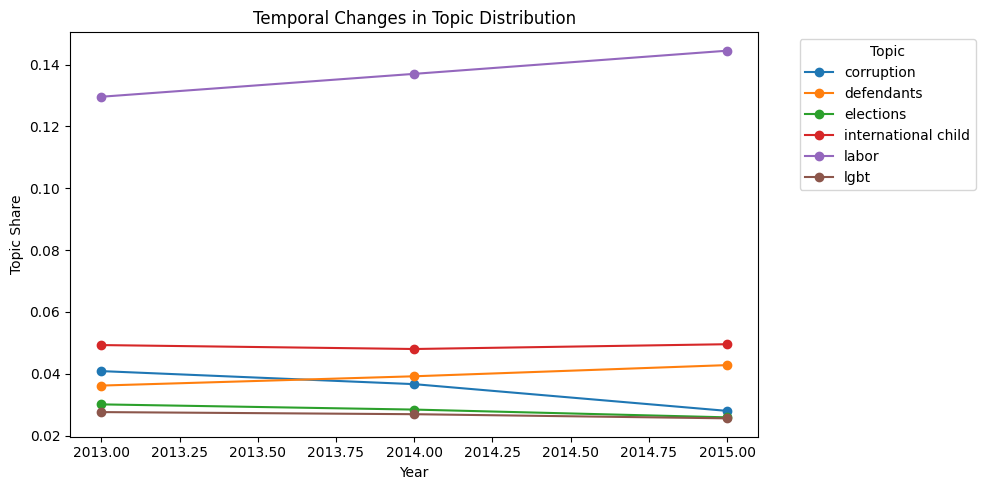

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

def ultra_short_label(label):
    if pd.isna(label):
        return "unknown"
    tokens = label.replace("/", ",").split(",")
    main = tokens[0].strip()
    return " ".join(main.split()[:2])

df_temp = df_topics.copy()

df_temp["topic_label_short"] = (
    df_temp["topic_name"]
    .apply(ultra_short_label)
)

# optional: remove outliers
df_temp = df_temp[df_temp["topic"] != -1]



topic_year_counts = df_temp.groupby(["year", "topic_label_short"]).size().reset_index(name="count")
topic_year_counts["share"] = topic_year_counts["count"] / topic_year_counts.groupby("year")["count"].transform("sum")
topic_year = topic_year_counts[["year", "topic_label_short", "share"]]

top_k = 6

top_topics = (
    df_temp["topic_label_short"]
    .value_counts()
    .head(top_k)
    .index
)

topic_year_top = topic_year[
    topic_year["topic_label_short"].isin(top_topics)
]

pivot = topic_year_top.pivot(
    index="year",
    columns="topic_label_short",
    values="share"
).fillna(0)

plt.figure(figsize=(10, 5))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        marker="o",
        label=col
    )

plt.xlabel("Year")
plt.ylabel("Topic Share")
plt.title("Temporal Changes in Topic Distribution")
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

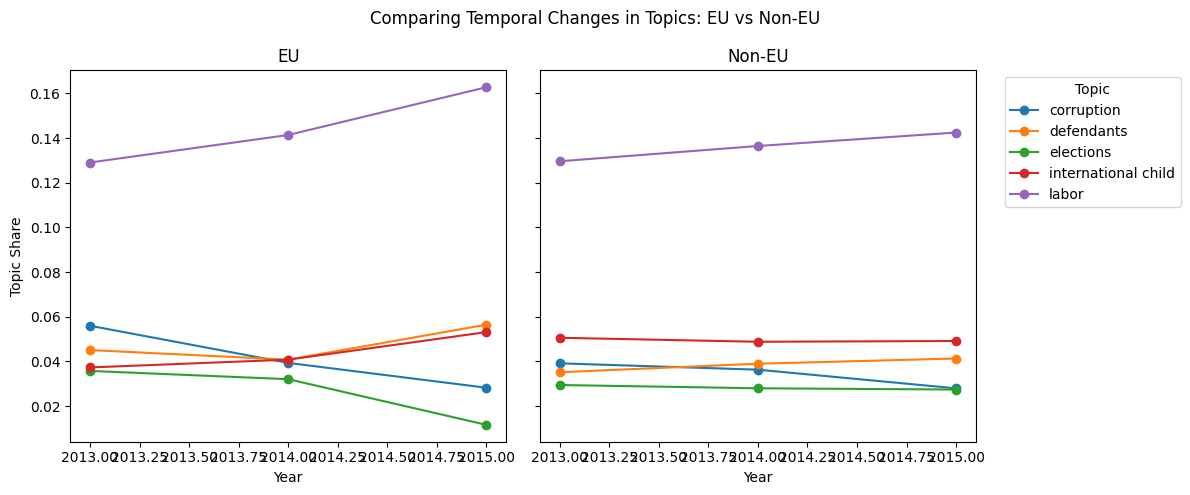

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

def ultra_short_label(label):
    if pd.isna(label):
        return "unknown"
    tokens = label.replace("/", ",").split(",")
    main = tokens[0].strip()
    return " ".join(main.split()[:2])


df_temp = df_topics.copy()

df_temp["topic_label_short"] = (
    df_temp["topic_name"]
    .apply(ultra_short_label)
)

# remove outliers if any
df_temp = df_temp[df_temp["topic"] != -1]


topic_year_group = (
    df_temp
    .groupby(["EU_status", "year", "topic_label_short"], as_index=False)
    .size()
)

topic_year_group["share"] = (
    topic_year_group["size"] /
    topic_year_group.groupby(["EU_status", "year"])["size"].transform("sum")
)

top_k = 5

top_topics = (
    df_temp["topic_label_short"]
    .value_counts()
    .head(top_k)
    .index
)

topic_year_group = topic_year_group[
    topic_year_group["topic_label_short"].isin(top_topics)
]


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, group in enumerate(["EU", "Non-EU"]):
    subset = topic_year_group[
        topic_year_group["EU_status"] == group
    ]

    pivot = subset.pivot(
        index="year",
        columns="topic_label_short",
        values="share"
    ).fillna(0)

    for col in pivot.columns:
        axes[i].plot(
            pivot.index,
            pivot[col],
            marker="o",
            label=col
        )

    axes[i].set_title(group)
    axes[i].set_xlabel("Year")

axes[0].set_ylabel("Topic Share")
axes[1].legend(
    title="Topic",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.suptitle("Comparing Temporal Changes in Topics: EU vs Non-EU")
plt.tight_layout()
plt.show()


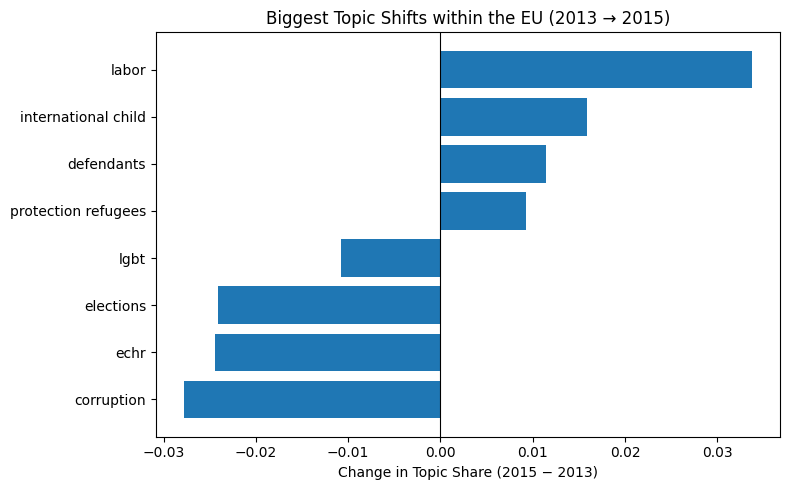

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

def ultra_short_label(label):
    if pd.isna(label):
        return "unknown"
    tokens = label.replace("/", ",").split(",")
    main = tokens[0].strip()
    return " ".join(main.split()[:2])


df_eu = df_topics.copy()

df_eu = df_eu[df_eu["EU_status"] == "EU"]
df_eu = df_eu[df_eu["topic"] != -1]

df_eu["topic_label_short"] = (
    df_eu["topic_name"]
    .apply(ultra_short_label)
)


topic_year_eu = (
    df_eu
    .groupby(["year", "topic_label_short"], as_index=False)
    .size()
)

topic_year_eu["share"] = (
    topic_year_eu["size"] /
    topic_year_eu.groupby("year")["size"].transform("sum")
)

pivot = topic_year_eu.pivot(
    index="topic_label_short",
    columns="year",
    values="share"
).fillna(0)

# keep only 2013 and 2015
pivot = pivot[[2013, 2015]]

pivot["shift_2013_2015"] = pivot[2015] - pivot[2013]

# select biggest absolute shifts
top_shifts = (
    pivot["shift_2013_2015"]
    .abs()
    .sort_values(ascending=False)
    .head(8)
    .index
)

shift_df = pivot.loc[top_shifts].sort_values("shift_2013_2015")


plt.figure(figsize=(8, 5))
plt.barh(
    shift_df.index,
    shift_df["shift_2013_2015"]
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Change in Topic Share (2015 − 2013)")
plt.title("Biggest Topic Shifts within the EU (2013 → 2015)")
plt.tight_layout()
plt.show()


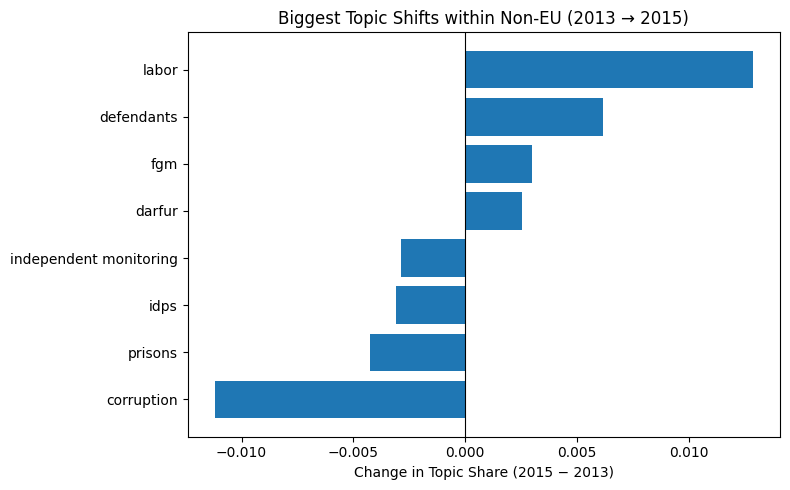

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

def ultra_short_label(label):
    if pd.isna(label):
        return "unknown"
    tokens = label.replace("/", ",").split(",")
    main = tokens[0].strip()
    return " ".join(main.split()[:2])


df_noneu = df_topics.copy()

df_noneu = df_noneu[df_noneu["EU_status"] == "Non-EU"]
df_noneu = df_noneu[df_noneu["topic"] != -1]

df_noneu["topic_label_short"] = (
    df_noneu["topic_name"]
    .apply(ultra_short_label)
)

topic_year_noneu = (
    df_noneu
    .groupby(["year", "topic_label_short"], as_index=False)
    .size()
)

topic_year_noneu["share"] = (
    topic_year_noneu["size"] /
    topic_year_noneu.groupby("year")["size"].transform("sum")
)

pivot = topic_year_noneu.pivot(
    index="topic_label_short",
    columns="year",
    values="share"
).fillna(0)

# keep only 2013 and 2015
pivot = pivot[[2013, 2015]]

pivot["shift_2013_2015"] = pivot[2015] - pivot[2013]

# select biggest absolute shifts
top_shifts = (
    pivot["shift_2013_2015"]
    .abs()
    .sort_values(ascending=False)
    .head(8)
    .index
)

shift_df = pivot.loc[top_shifts].sort_values("shift_2013_2015")


plt.figure(figsize=(8, 5))
plt.barh(
    shift_df.index,
    shift_df["shift_2013_2015"]
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Change in Topic Share (2015 − 2013)")
plt.title("Biggest Topic Shifts within Non-EU (2013 → 2015)")
plt.tight_layout()
plt.show()
